# Analysis of mirror codes
This is a high-level wrapper of the mirror code and benchmarking functionalities of this repository, enabling benchmarking of a chosen mirror code.

In [1]:
from mirror import MirrorCode
from benchmark import StabilizerCode, make_noise_model
import numpy as np
import matplotlib.pyplot as plt
import stim
import sinter
from tesseract_decoder import make_tesseract_sinter_decoders_dict, TesseractSinterDecoder
import tesseract_decoder

As an example, let us benchmark the `[[n, k, d, w]] = [[36, 6, 6, 6]]` code.

In [2]:
# [[36, 6, 6, 6]] code
code = MirrorCode(
        group = [2, 2, 3, 3],
        z0 = [[0, 0, 0, 0],
       [0, 1, 0, 1],
       [1, 0, 0, 2]],
        x0 = [[0, 0, 0, 0],
       [0, 1, 1, 0],
       [1, 1, 2, 0]]
    )

CODE_NAME = "[[36, 6, 6]]"
NOISE_MODEL_NAME = "SI1000"

In [3]:
print("Finding stabilizers...")
stabilizers = code.get_stim_tableau()
print("Done.")

benchmarker = StabilizerCode(stabilizers, verbose=False, name=CODE_NAME)

T = 6 # min error rate is 10^-T
NUM_PROBS = 8

# Define the main parameters of the benchmarking
ROUND_CHOICES = [3, 6, 9]
PS = np.logspace(-T, -2, NUM_PROBS)
NUM_SHOTS = 50_000

print("Making syndrome extraction circuits...")
SECS = [code.bare_ancilla_sec(noise=make_noise_model(PS[i], NOISE_MODEL_NAME),
                              num_rounds=nrd
                              )
                            for nrd in ROUND_CHOICES
                            for i in range(len(PS))
        ]
print("Done")

Finding stabilizers...
Done.
Making syndrome extraction circuits...
Done


Starting 8 workers...
24 tasks left:
  workers   decoder eta shots_left errors_seen json_metadata                                      
        1 tesseract   ?      50000           0 p=1e-06,decoder=tesseract,rounds=3                 
        1 tesseract   ?      50000           0 p=1e-06,decoder=tesseract,rounds=6                 
        1 tesseract   ?      50000           0 p=1e-06,decoder=tesseract,rounds=9                 
        1 tesseract   ?      50000           0 p=3.727593720314938e-06,decoder=tesseract,rounds=3 
        1 tesseract   ?      50000           0 p=3.727593720314938e-06,decoder=tesseract,rounds=6 
        1 tesseract <1m      47679           0 p=3.727593720314938e-06,decoder=tesseract,rounds=9 
        1 tesseract   ?      50000           0 p=1.3894954943731361e-05,decoder=tesseract,rounds=3
        1 tesseract   ?      50000           0 p=1.3894954943731361e-05,decoder=tesseract,rounds=6
        0 tesseract ?·∞      50000           0 p=1.3894954943731361e-05,

19 tasks left:
  workers   decoder eta shots_left errors_seen json_metadata                                      
        1 tesseract <1m      10815          18 p=3.727593720314938e-06,decoder=tesseract,rounds=9 
        1 tesseract <1m      30271          17 p=1.3894954943731361e-05,decoder=tesseract,rounds=3
        1 tesseract <1m      33343          24 p=1.3894954943731361e-05,decoder=tesseract,rounds=6
        1 tesseract   ?      50000           0 p=1.3894954943731361e-05,decoder=tesseract,rounds=9
        1 tesseract   ?      50000           0 p=5.1794746792312125e-05,decoder=tesseract,rounds=3
        1 tesseract   ?      50000           0 p=5.1794746792312125e-05,decoder=tesseract,rounds=6
        1 tesseract   ?      50000           0 p=5.1794746792312125e-05,decoder=tesseract,rounds=9
        1 tesseract   ?      50000           0 p=0.00019306977288832496,decoder=tesseract,rounds=3
        0 tesseract ?·∞      50000           0 p=0.00019306977288832496,decoder=tesseract,roun

18 tasks left:
  workers   decoder eta shots_left errors_seen json_metadata                                      
        1 tesseract <1m      12863          38 p=1.3894954943731361e-05,decoder=tesseract,rounds=3
        1 tesseract <1m      15935          55 p=1.3894954943731361e-05,decoder=tesseract,rounds=6
        1 tesseract <1m      31295          22 p=1.3894954943731361e-05,decoder=tesseract,rounds=9
        1 tesseract <1m      44607          20 p=5.1794746792312125e-05,decoder=tesseract,rounds=3
        1 tesseract <1m      44607          30 p=5.1794746792312125e-05,decoder=tesseract,rounds=6
        1 tesseract <1m      47679          16 p=5.1794746792312125e-05,decoder=tesseract,rounds=9
        1 tesseract <1m      49727           6 p=0.00019306977288832496,decoder=tesseract,rounds=3
        1 tesseract <1m      49727           5 p=0.00019306977288832496,decoder=tesseract,rounds=6
        0 tesseract ?·∞      50000           0 p=0.00019306977288832496,decoder=tesseract,roun

15 tasks left:
  workers   decoder eta shots_left errors_seen json_metadata                                      
        1 tesseract <1m      36415          65 p=5.1794746792312125e-05,decoder=tesseract,rounds=3
        1 tesseract <1m      35391          80 p=5.1794746792312125e-05,decoder=tesseract,rounds=6
        1 tesseract <1m      35391          81 p=5.1794746792312125e-05,decoder=tesseract,rounds=9
        1 tesseract <1m      46655          73 p=0.00019306977288832496,decoder=tesseract,rounds=3
        1 tesseract <1m      46655          63 p=0.00019306977288832496,decoder=tesseract,rounds=6
        1 tesseract <1m      48703          34 p=0.00019306977288832496,decoder=tesseract,rounds=9
        1 tesseract <1m      49727          22 p=0.0007196856730011514,decoder=tesseract,rounds=3 
        1 tesseract   ?      50000           0 p=0.0007196856730011514,decoder=tesseract,rounds=6 
        0 tesseract ?·∞      50000           0 p=0.0007196856730011514,decoder=tesseract,round

15 tasks left:
  workers   decoder eta shots_left errors_seen json_metadata                                      
        1 tesseract <1m      31295         102 p=5.1794746792312125e-05,decoder=tesseract,rounds=3
        1 tesseract <1m      30271         107 p=5.1794746792312125e-05,decoder=tesseract,rounds=6
        1 tesseract <1m      30271         107 p=5.1794746792312125e-05,decoder=tesseract,rounds=9
        1 tesseract <1m      44607         122 p=0.00019306977288832496,decoder=tesseract,rounds=3
        1 tesseract <1m      44607         109 p=0.00019306977288832496,decoder=tesseract,rounds=6
        1 tesseract <1m      46655          71 p=0.00019306977288832496,decoder=tesseract,rounds=9
        1 tesseract <1m      49727          22 p=0.0007196856730011514,decoder=tesseract,rounds=3 
        1 tesseract <1m      49727          20 p=0.0007196856730011514,decoder=tesseract,rounds=6 
        0 tesseract ?·∞      50000           0 p=0.0007196856730011514,decoder=tesseract,round

...

4 tasks left:
  workers   decoder eta shots_left errors_seen json_metadata                                     
        2 tesseract <1m      25966        7420 p=0.0026826957952797246,decoder=tesseract,rounds=9
        2 tesseract 35m      48902         998 p=0.01,decoder=tesseract,rounds=3                 
        2 tesseract 35m      48910        1004 p=0.01,decoder=tesseract,rounds=6                 
        2 tesseract 39m      49282         667 p=0.01,decoder=tesseract,rounds=9                 
4 tasks left:
  workers   decoder eta shots_left errors_seen json_metadata                                     
        2 tesseract <1m      25966        7420 p=0.0026826957952797246,decoder=tesseract,rounds=9
        2 tesseract 35m      48902         998 p=0.01,decoder=tesseract,rounds=3                 
        2 tesseract 35m      48908        1005 p=0.01,decoder=tesseract,rounds=6                 
        2 tesseract 39m      49282         667 p=0.01,decoder=tesseract,rounds=9          

3 tasks left:
  workers   decoder eta shots_left errors_seen json_metadata                    
        3 tesseract 24m      48101        1734 p=0.01,decoder=tesseract,rounds=3
        3 tesseract 23m      48092        1763 p=0.01,decoder=tesseract,rounds=6
        2 tesseract 37m      48202        1671 p=0.01,decoder=tesseract,rounds=9
3 tasks left:
  workers   decoder eta shots_left errors_seen json_metadata                    
        3 tesseract 24m      48093        1741 p=0.01,decoder=tesseract,rounds=3
        3 tesseract 23m      48092        1763 p=0.01,decoder=tesseract,rounds=6
        2 tesseract 37m      48202        1671 p=0.01,decoder=tesseract,rounds=9
3 tasks left:
  workers   decoder eta shots_left errors_seen json_metadata                    
        3 tesseract 24m      48085        1748 p=0.01,decoder=tesseract,rounds=3
        3 tesseract 23m      48092        1763 p=0.01,decoder=tesseract,rounds=6
        2 tesseract 37m      48202        1671 p=0.01,decoder=tesse

2 tasks left:
  workers   decoder eta shots_left errors_seen json_metadata                    
        4 tesseract <1m        803       45359 p=0.01,decoder=tesseract,rounds=3
        4 tesseract  6m      17005       30341 p=0.01,decoder=tesseract,rounds=9
2 tasks left:
  workers   decoder eta shots_left errors_seen json_metadata                    
        4 tesseract <1m        803       45359 p=0.01,decoder=tesseract,rounds=3
        4 tesseract  6m      17004       30342 p=0.01,decoder=tesseract,rounds=9
2 tasks left:
  workers   decoder eta shots_left errors_seen json_metadata                    
        4 tesseract <1m        803       45359 p=0.01,decoder=tesseract,rounds=3
        4 tesseract  6m      17002       30344 p=0.01,decoder=tesseract,rounds=9
2 tasks left:
  workers   decoder eta shots_left errors_seen json_metadata                    
        4 tesseract <1m        799       45362 p=0.01,decoder=tesseract,rounds=3
        4 tesseract  6m      17002       30344 p=0.01

1 tasks left:
  workers   decoder eta shots_left errors_seen json_metadata                    
        8 tesseract  3m      16859       30479 p=0.01,decoder=tesseract,rounds=9
1 tasks left:
  workers   decoder eta shots_left errors_seen json_metadata                    
        8 tesseract  3m      16851       30487 p=0.01,decoder=tesseract,rounds=9
1 tasks left:
  workers   decoder eta shots_left errors_seen json_metadata                    
        8 tesseract  3m      16848       30490 p=0.01,decoder=tesseract,rounds=9
1 tasks left:
  workers   decoder eta shots_left errors_seen json_metadata                    
        8 tesseract  3m      16840       30497 p=0.01,decoder=tesseract,rounds=9
1 tasks left:
  workers   decoder eta shots_left errors_seen json_metadata                    
        8 tesseract  3m      16832       30505 p=0.01,decoder=tesseract,rounds=9
1 tasks left:
  workers   decoder eta shots_left errors_seen json_metadata                    
        8 tesseract  3m  

     shots,    errors,  discards, seconds,decoder,strong_id,json_metadata,custom_counts
     50000,        23,         0,   0.225,tesseract,8d9cd149abaffd7e18074664ad0a684907ba2027cff2eccd697660845c12f492,"{""decoder"":""tesseract"",""p"":3.727593720314938e-06,""rounds"":9}",
     50000,        28,         0,   0.209,tesseract,77953ab0d17311e921b002771fea7dd339ad0d4f71d93224c5db795002691171,"{""decoder"":""tesseract"",""p"":3.727593720314938e-06,""rounds"":3}",
     50000,         5,         0,   0.124,tesseract,ea07e6ff340b6485af8c2d550c20b2a2a8e6ca74b17bc9ec680044ab904795d1,"{""decoder"":""tesseract"",""p"":1e-06,""rounds"":9}",
     50000,         2,         0,   0.115,tesseract,6574fb9ae0fc54363b656abc6f31a457496715f9289e3dc557139f33b0eb55b7,"{""decoder"":""tesseract"",""p"":1e-06,""rounds"":3}",
     50000,        31,         0,   0.204,tesseract,ee98b5b5ccc95ecd0655ecd8c5677b8fab231a35730f2984bf01ef1ffed3834a,"{""decoder"":""tesseract"",""p"":3.727593720314938e-06,""rounds"":6}",

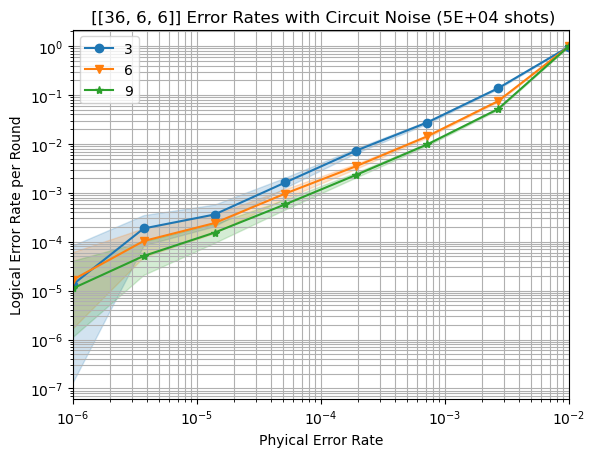

In [4]:
sinter_stats = benchmarker.sinter_benchmark(ps=PS,
                               secs=SECS,
                               rounds_choices=ROUND_CHOICES,
                               num_shots=NUM_SHOTS,
                               plot=True,
                               verbose=True
                               )